In [1]:
import os
import torch
import torchvision
import tarfile
from torchvision.datasets.utils import download_url
from torch.utils.data import random_split

In [2]:
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

In [3]:
import torch.nn as nn
import torch.nn.functional as F

In [4]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("akash2sharma/tiny-imagenet")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\Prasad\.cache\kagglehub\datasets\akash2sharma\tiny-imagenet\versions\1


# added tiny-imagenet-200 in the path¶

In [5]:
data_path = r"C:\Users\Prasad\.cache\kagglehub\datasets\akash2sharma\tiny-imagenet\versions\1\tiny-imagenet-200"

In [6]:
os.listdir(data_path)

['test', 'train', 'val', 'wnids.txt', 'words.txt']

In [7]:
from torchvision.datasets import ImageFolder
from torchvision.transforms import ToTensor

train_ds = ImageFolder(data_path+'/train', transform=ToTensor())

In [8]:
train_ds

Dataset ImageFolder
    Number of datapoints: 100000
    Root location: C:\Users\Prasad\.cache\kagglehub\datasets\akash2sharma\tiny-imagenet\versions\1\tiny-imagenet-200/train
    StandardTransform
Transform: ToTensor()

C:\Users\Prasad\AppData\Local\Temp\ipykernel_24296\907974899.py:2: UserWarning: The use of `x.T` on tensors of dimension other than 2 to reverse their shape is deprecated and it will throw an error in a future release. Consider `x.mT` to transpose batches of matrices or `x.permute(*torch.arange(x.ndim - 1, -1, -1))` to reverse the dimensions of a tensor. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\aten\src\ATen\native\TensorShape.cpp:3687.)
  plt.imshow(img.T)


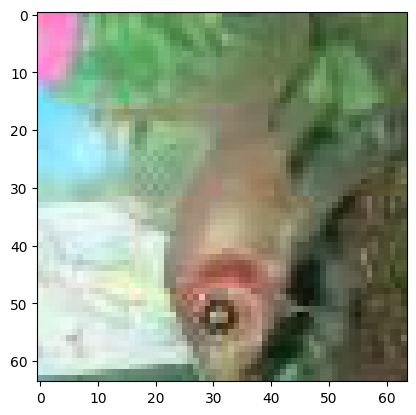

In [9]:
img, label = train_ds[0]
plt.imshow(img.T)
plt.show()

In [10]:
img.shape

torch.Size([3, 64, 64])

In [11]:
val_ds = ImageFolder(data_path+'/val', transform=ToTensor())

In [12]:
val_ds.classes

['images']

In [13]:
train_ds.classes

['n01443537',
 'n01629819',
 'n01641577',
 'n01644900',
 'n01698640',
 'n01742172',
 'n01768244',
 'n01770393',
 'n01774384',
 'n01774750',
 'n01784675',
 'n01855672',
 'n01882714',
 'n01910747',
 'n01917289',
 'n01944390',
 'n01945685',
 'n01950731',
 'n01983481',
 'n01984695',
 'n02002724',
 'n02056570',
 'n02058221',
 'n02074367',
 'n02085620',
 'n02094433',
 'n02099601',
 'n02099712',
 'n02106662',
 'n02113799',
 'n02123045',
 'n02123394',
 'n02124075',
 'n02125311',
 'n02129165',
 'n02132136',
 'n02165456',
 'n02190166',
 'n02206856',
 'n02226429',
 'n02231487',
 'n02233338',
 'n02236044',
 'n02268443',
 'n02279972',
 'n02281406',
 'n02321529',
 'n02364673',
 'n02395406',
 'n02403003',
 'n02410509',
 'n02415577',
 'n02423022',
 'n02437312',
 'n02480495',
 'n02481823',
 'n02486410',
 'n02504458',
 'n02509815',
 'n02666196',
 'n02669723',
 'n02699494',
 'n02730930',
 'n02769748',
 'n02788148',
 'n02791270',
 'n02793495',
 'n02795169',
 'n02802426',
 'n02808440',
 'n02814533',
 'n028

In [14]:
test_data = ImageFolder(data_path+'/test', transform=ToTensor())

In [15]:
test_data

Dataset ImageFolder
    Number of datapoints: 10000
    Root location: C:\Users\Prasad\.cache\kagglehub\datasets\akash2sharma\tiny-imagenet\versions\1\tiny-imagenet-200/test
    StandardTransform
Transform: ToTensor()

In [16]:
test_data.classes

['images']

# train_ds, val_ds, test_data

In [17]:
from torch.utils.data.dataloader import DataLoader

batch_size = 128

train_dl = DataLoader(train_ds, batch_size, shuffle=True, num_workers=4, pin_memory=True)
val_dl = DataLoader(val_ds, batch_size, shuffle=True, num_workers = 4, pin_memory= True)

In [18]:
for images, labels in train_dl:
    print('images.shape:', images.shape)
    break

images.shape: torch.Size([128, 3, 64, 64])


In [19]:
class ImageClassificationBase(nn.Module):
    def training_step(self, batch):
        images, labels = batch
        out = self(images)
        loss = F.cross_entropy(out, labels)
        return loss
    def validation_step(self, batch):
        images, labels = batch
        out  = self(images)
        loss = F.cross_entropy(out, labels)
        acc = self.accuracy(out, labels)
        return {'val_loss' :loss.detach(), 'val_acc':acc}
    def validation_epoch_end(self, outputs):
        batch_losses = [x['val_loss'] for x in outputs]
        epoch_loss = torch.stack(batch_losses).mean()
        batch_accs = [x['val_acc'] for x in outputs]
        epoch_accs = torch.stack(batch_accs).mean()
        return {'val_loss':epoch_loss.item(), 'val_acc':epoch_accs.item()}
    def epoch_end(self, epoch, result):
        print("Epoch [{}], train_loss: {:.4f}, val_loss: {:.4f}, val_acc:{:.4f}".format(
            epoch, result['train_loss'], result['val_loss'], result['val_acc']
        ))
    @torch.no_grad()
    def evaluate(self, val_loader):
        outputs = [self.validation_step(batch) for batch in val_loader]
        return self.validation_epoch_end(outputs)
    def accuracy(self, outputs, labels):
        _,preds = torch.max(outputs, dim=1)
        return torch.tensor(torch.sum(preds == labels).item()/ len(preds))

In [29]:
class TinyImagenetCnnModel(ImageClassificationBase):
    def __init__(self):
        super().__init__()
        self.network = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, stride=1,padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2), 

            nn.Conv2d(128, 256, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.Conv2d(256, 256, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2), 

            nn.Conv2d(256, 1024, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.Conv2d(1024, 1024, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Flatten(), 
            nn.Linear(1024*8*8, 2048),
            nn.ReLU(),
            nn.Linear(2048, 65536),
            nn.ReLU(),
            nn.Linear(65536, 200))
        
    def forward(self, xb):
        return self.network(xb)

In [30]:
def get_default_device():
    """Pick GPU if available, else CPU"""
    if torch.cuda.is_available():
        return torch.device('cuda')
    else:
        return torch.device('cpu')
    
def to_device(data, device):
    """Move tensor(s) to chosen device"""
    if isinstance(data, (list,tuple)):
        return [to_device(x, device) for x in data]
    return data.to(device, non_blocking=True)

class DeviceDataLoader():
    """Wrap a dataloader to move data to a device"""
    def __init__(self, dl, device):
        self.dl = dl
        self.device = device
        
    def __iter__(self):
        """Yield a batch of data after moving it to device"""
        for b in self.dl: 
            yield to_device(b, self.device)

    def __len__(self):
        """Number of batches"""
        return len(self.dl)

In [31]:
device = get_default_device()
device

device(type='cuda')

In [32]:
model = TinyImagenetCnnModel()

In [33]:
model_imagenet = to_device(model , device)


In [34]:
train_dl = DeviceDataLoader(train_dl, device)
val_dl = DeviceDataLoader(val_dl, device)
to_device(model_imagenet, device);

In [35]:
model_imagenet.evaluate(val_dl)

{'val_loss': 5.302048206329346, 'val_acc': 0.0}

In [36]:
def fit(epochs, lr, model, train_loader, val_loader, opt_func=torch.optim.SGD):
    history = []
    optimizer = opt_func(model.parameters(), lr)
    for epoch in range(epochs):
        # Training Phase 
        model.train()
        train_losses = []
        for batch in train_loader:
            loss = model.training_step(batch)
            train_losses.append(loss)
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
        # Validation phase
        result = model.evaluate(val_loader)
        result['train_loss'] = torch.stack(train_losses).mean().item()
        model.epoch_end(epoch, result)
        history.append(result)
    return history

In [ ]:
num_epochs = 10
opt_func = torch.optim.Adam
lr = 0.001

history = fit(num_epochs, lr, model, train_dl, val_dl, opt_func)

Epoch [0], train_loss: 5.3223, val_loss: 5.2971, val_acc:0.0000


In [ ]:
def predict_image(img, model):
    xb = to_device(img,unaqueeze(0), device)
    yb = model(xb)
    _, preds = torch.max(yb, dim=1)
    return dataset.classes[preds[0].item()]

In [ ]:
torch.save(model_imagenet.state_dict(), 'tinyimagenet-cnn.pth')

The primary difference between Conv1d, Conv2d, and Conv3d lies in the dimensionality of the input data and the direction in which the convolutional kernel (filter) slides. They are designed to extract local patterns from data with different spatial

* Conv1d: Slides in 1 dimension (e.g., along a sequence).
* Conv2d: Slides in 2 dimensions (e.g., width and height of an image).
* Conv3d: Slides in 3 dimensions (e.g., width, height, and depth/time).

1. Conv1d (1-Dimensional Convolution)
* Usage: Used for sequential data where the ordering matters, such as natural language processing (text) or time-series data (e.g., accelerometer data, audio signals).
* How it works: The filter moves along the sequence length. It looks for local patterns in a 1D sequence.
* Example: A 1-second audio signal, sampled at 44.1 kHz, has a 1D structure. 
Data Science Stack Exchange
Data Science Stack Exchange

2. Conv2d (2-Dimensional Convolution)
* Usage: The standard for computer vision tasks, including image classification, object detection, and image segmentation.
* How it works: The filter slides across the height and width of an image, extracting features like edges, corners, or specific textures.
* Example: A 32x32 RGB image, shape (Batch, 3, 32, 32). 
Data Science Stack Exchange
Data Science Stack Exchange

3. Conv3d (3-Dimensional Convolution)
* Usage: Used for volumetric data or video, where there is a third dimension (time or depth) in addition to spatial dimensions.
* How it works: The filter slides across three dimensions, such as video frames over time (width, height, time).
* Example: Medical imaging (MRI/CT scans) or a video sequence, shape (Batch, Channels, Time, Height, Width). 
Stack Overflow
Stack Overflow
 
4. ConvTranspose1d / 2d / 3d (Transposed Convolution) 
* Difference: While Conv1d acts as a "shrinking" convolution (downsampling), ConvTranspose1d is essentially an "expanding" convolution (upsampling) used to increase the dimensionality of the output. It is commonly used in autoencoders or generative models to reconstruct data. 

__Summary of Differences__
* Input Data: Conv1d for sequence, Conv2d for image, Conv3d for video/volume.
* Kernel movement: 1D, 2D, or 3D directions.
* Computational Cost: Conv1d is generally more efficient for sequential data than using 2D convolutions.

| Left-aligned | Center-aligned | Right-aligned |
|:---|:---:|---:|
| Data A | Data B | Data C |
| Data D | Data E | Data F |


| Feature |	Conv1d	|Conv2d	| Conv3d |
|:---|:---:|:---:|---:|
|Dimensions|	1D (Time/Sequence)	|2D (Spatial/Image)	|3D (Volumetric/Video)|
|Input Shape|	(Batch, Channels, Length)	|(Batch, Channels, Height, Width)	|(Batch, Channels, Depth, Height, Width)|
|Kernel Motion	|Moves along 1 axis	|Moves along 2 axes|	Moves along 3 axes|
|Typical Data |	Time-series, Audio, Text |	Images, Spectrograms |	MRI scans, Video, 3D medical data|
|Parameter Size |	Fewer (1D kernel) |	Moderate (2D kernel) |	Higher (3D kernel)|
